In [6]:
from typing import List, Dict, Union
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from siglab_py.util.simple_math import bucket_series, bucketize_val

##### Load trade file

In [7]:
trade_file = r"D:\dev\siglab\historical_trades_OKX_BTC_20260601.csv"
pd_historical_trades = pd.read_csv(trade_file)
pd_historical_trades.drop(pd_historical_trades.columns[pd_historical_trades.columns.str.contains('unnamed',case = False)],axis = 1, inplace = True)
pd_historical_trades.drop(['info'],axis = 1, inplace = True)
pd_historical_trades['timestamp_ms'] = pd_historical_trades['timestamp_ms'].astype('Int64')
pd_historical_trades

,timestamp_ms,datetime,symbol,id,order,type,takerOrMaker,side,price,amount_base_ccy,...,year,month,day,hour,minute,dayofweek,week_of_month,apac_trading_hr,emea_trading_hr,amer_trading_hr
0,1780306579108,2026-06-01 17:36:19,BTC/USDT:USDT,2638535405,NaN,NaN,NaN,buy,72912.0,0.06,...,2026,6,1,17,36,0,2,False,True,True
1,1780306579108,2026-06-01 17:36:19,BTC/USDT:USDT,2638535406,NaN,NaN,NaN,buy,72912.0,0.06,...,2026,6,1,17,36,0,2,False,True,True
2,1780306579109,2026-06-01 17:36:19,BTC/USDT:USDT,2638535409,NaN,NaN,NaN,sell,72911.9,2.79,...,2026,6,1,17,36,0,2,False,True,True
3,1780306579109,2026-06-01 17:36:19,BTC/USDT:USDT,2638535407,NaN,NaN,NaN,buy,72912.0,0.15,...,2026,6,1,17,36,0,2,False,True,True
4,1780306579109,2026-06-01 17:36:19,BTC/USDT:USDT,2638535408,NaN,NaN,NaN,buy,72912.0,0.04,...,2026,6,1,17,36,0,2,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398914,1780329587749,2026-06-01 23:59:47,BTC/USDT:USDT,2639993930,NaN,NaN,NaN,buy,71108.9,5.54,...,2026,6,1,23,59,0,2,False,True,True
398915,1780329587760,2026-06-01 23:59:47,BTC/USDT:USDT,2639993931,NaN,NaN,NaN,buy,71108.9,0.70,...,2026,6,1,23,59,0,2,False,True,True
398916,1780329587800,2026-06-01 23:59:47,BTC/USDT:USDT,2639993932,NaN,NaN,NaN,sell,71108.8,0.01,...,2026,6,1,23,59,0,2,False,True,True
398917,1780329587826,2026-06-01 23:59:47,BTC/USDT:USDT,2639993933,NaN,NaN,NaN,buy,71108.9,2.08,...,2026,6,1,23,59,0,2,False,True,True


In [8]:
min_datetime = pd_historical_trades['datetime'].min()
max_datetime = pd_historical_trades['datetime'].max()
amount_quote_ccy_min = pd_historical_trades['amount_quote_ccy'].min()
amount_quote_ccy_max = pd_historical_trades['amount_quote_ccy'].max()
amount_quote_ccy_mean = pd_historical_trades['amount_quote_ccy'].mean()
amount_quote_ccy_sum = pd_historical_trades['amount_quote_ccy'].sum()

summary = {
    "min_datetime" : min_datetime,
    "max_datetime" : max_datetime,
    "amount_quote_ccy_min": f"{amount_quote_ccy_min:,.0f}",
    "amount_quote_ccy_max": f"{amount_quote_ccy_max:,.0f}",
    "amount_quote_ccy_mean": f"{amount_quote_ccy_mean:,.2f}",
    "amount_quote_ccy_sum": f"{amount_quote_ccy_sum:,.0f}"
}

summary


{'min_datetime': '2026-06-01 17:36:19',
 'max_datetime': '2026-06-01 23:59:47',
 'amount_quote_ccy_min': '711',
 'amount_quote_ccy_max': '339,100,354',
 'amount_quote_ccy_mean': '233,719.52',
 'amount_quote_ccy_sum': '93,235,155,725'}

##### Bucketize amount_quote_ccy column

In [9]:
MIN_AMOUNT_QUOTE_CCY = 1_000_000
MAX_AMOUNT_QUOTE_CCY = 10_000_000

In [10]:
_pd_historical_trades = pd_historical_trades[(pd_historical_trades.amount_quote_ccy>=MIN_AMOUNT_QUOTE_CCY) & (pd_historical_trades.amount_quote_ccy<=MAX_AMOUNT_QUOTE_CCY)]

In [11]:
level_granularity = 0.1

amount_quote_values = _pd_historical_trades['amount_quote_ccy'].tolist()

buckets : Dict[
            str, 
            Dict[str,Union[float, List[float]]]
        ] = bucket_series(
                                                values = amount_quote_values,
                                                outlier_threshold_percent = 10,
                                                level_granularity=level_granularity
                                            )
        
pd_historical_trades['amount_quote_ccy_bucket'] = pd_historical_trades['amount_quote_ccy'].apply(
    lambda x: bucketize_val(x, buckets)
)

In [12]:
selected_columns = ['symbol', 'datetime', 'timestamp_ms', 'id', 'side', 'price', 
                   'amount_base_ccy', 'amount_quote_ccy', 'amount_quote_ccy_bucket', 
                   'datetime_utc', 'year', 'month', 'day', 'hour', 'minute', 
                   'dayofweek', 'week_of_month', 'apac_trading_hr', 'emea_trading_hr', 
                   'amer_trading_hr']
pd_historical_trades = pd_historical_trades[selected_columns]

styled = pd_historical_trades[:10].style.format({
    'amount_base_ccy': '{:,.2f}',
    'amount_quote_ccy': '{:,.2f}'
})
styled

,symbol,datetime,timestamp_ms,id,side,price,amount_base_ccy,amount_quote_ccy,amount_quote_ccy_bucket,datetime_utc,year,month,day,hour,minute,dayofweek,week_of_month,apac_trading_hr,emea_trading_hr,amer_trading_hr
0,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579108,2638535405,buy,72912.000000,0.06,"4,374.72",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
1,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579108,2638535406,buy,72912.000000,0.06,"4,374.72",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
2,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579109,2638535409,sell,72911.900000,2.79,"203,424.20",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
3,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579109,2638535407,buy,72912.000000,0.15,"10,936.80",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
4,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579109,2638535408,buy,72912.000000,0.04,"2,916.48",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
5,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579111,2638535410,buy,72912.000000,4.33,"315,708.96",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
6,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579596,2638535411,buy,72912.000000,0.68,"49,580.16",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
7,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579812,2638535412,sell,72911.900000,0.01,729.12,< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
8,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579812,2638535413,sell,72911.900000,0.04,"2,916.48",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True
9,BTC/USDT:USDT,2026-06-01 17:36:19,1780306579876,2638535414,sell,72911.900000,6.55,"477,572.95",< 1000000,2026-06-01 09:36:19+00:00,2026,6,1,17,36,0,2,False,True,True


In [13]:
grouped = pd_historical_trades.groupby(['amount_quote_ccy_bucket']).agg(
    simple_count=('id', 'size'),
    sum_amount_quote_ccy=('amount_quote_ccy', 'sum'),
).reset_index()
grouped['sum_amount_quote_ccy'] = grouped['sum_amount_quote_ccy'].round(0)

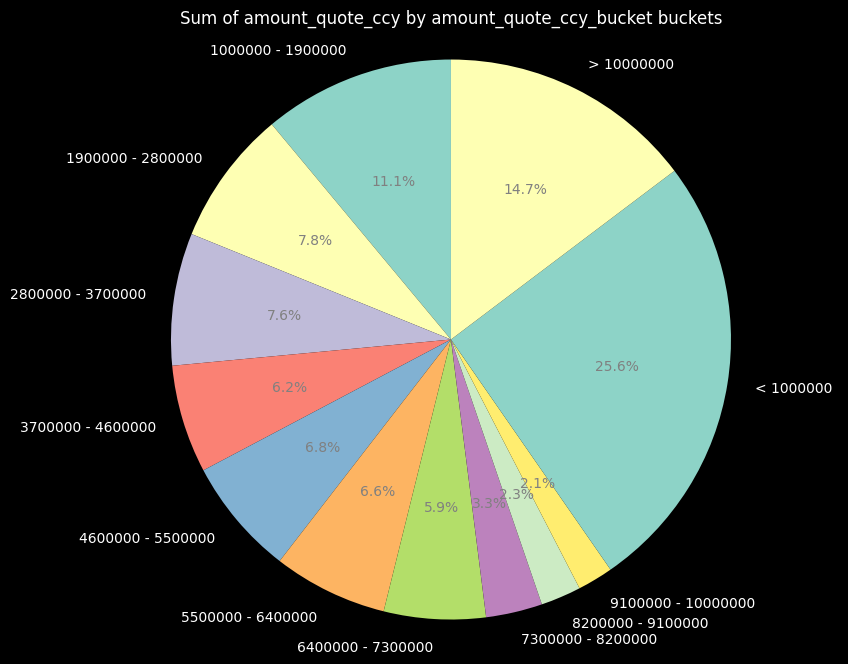

In [14]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(grouped['sum_amount_quote_ccy'], 
                                  labels=grouped['amount_quote_ccy_bucket'], 
                                  autopct='%1.1f%%', 
                                  startangle=90)
for autotext in autotexts:
    autotext.set_color('gray')
ax.set_title('Sum of amount_quote_ccy by amount_quote_ccy_bucket buckets')
ax.axis('equal')
plt.show()

In [15]:
grouped['sum_amount_quote_ccy'] = grouped['sum_amount_quote_ccy'].round(0).astype(int).apply(lambda x: f'{x:,}')
grouped

,amount_quote_ccy_bucket,simple_count,sum_amount_quote_ccy
0,1000000 - 1900000,7480,"10,304,372,239"
1,1900000 - 2800000,3205,"7,275,146,232"
2,2800000 - 3700000,2188,"7,122,283,046"
3,3700000 - 4600000,1405,"5,819,786,941"
4,4600000 - 5500000,1246,"6,326,486,734"
5,5500000 - 6400000,1038,"6,165,444,214"
6,6400000 - 7300000,800,"5,474,556,789"
7,7300000 - 8200000,396,"3,036,748,176"
8,8200000 - 9100000,252,"2,171,712,291"
9,9100000 - 10000000,201,"1,919,714,367"


##### Histogram on amount_quote_ccy, over focused notional ranges

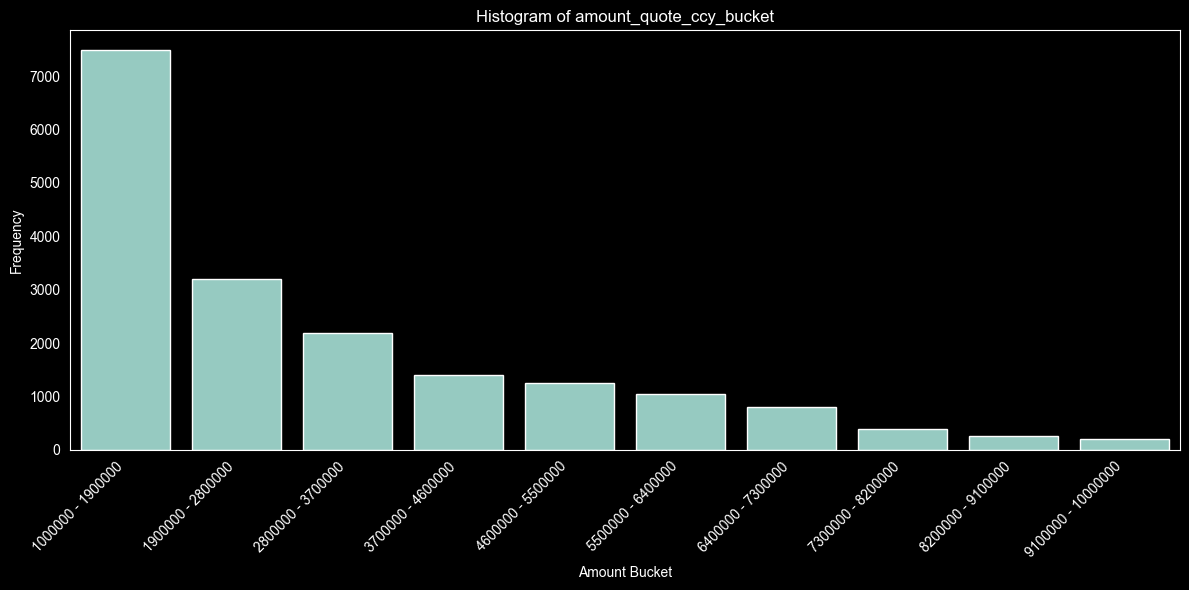

In [16]:
_pd_historical_trades = pd_historical_trades[(pd_historical_trades.amount_quote_ccy>=MIN_AMOUNT_QUOTE_CCY) & (pd_historical_trades.amount_quote_ccy<=MAX_AMOUNT_QUOTE_CCY)]

sns.set_style('dark')
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

bucket_order = sorted(_pd_historical_trades['amount_quote_ccy_bucket'].unique(),
                      key=lambda x: float(x.split(' - ')[0].replace('< ', '').replace('> ', '')))

sns.countplot(
    data=_pd_historical_trades,
    x='amount_quote_ccy_bucket',
    order=bucket_order,
    edgecolor='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')
plt.xlabel('Amount Bucket', color='white')
plt.ylabel('Frequency', color='white')
plt.title('Histogram of amount_quote_ccy_bucket', color='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
ax.grid(False)
plt.tight_layout()
plt.show()